# LLM 전체 데이터 문항별 평가 노트북 - 상세 설명

## 이 노트북의 목적
GPT-4o + P9(Hard Tiebreaker) 프롬프트로 **전체 2,080개 피드백 데이터**를 예측하고,
문항별/유형별 성능을 ML/BERT와 비교합니다.

## 이전 실험과의 차이점
- **이전 실험(01_experiment)**: 테스트셋(416개)만 대상, 여러 프롬프트 비교
- **이 실험**: 전체 데이터(2,080개), 최적 프롬프트(P9)만 사용, 문항별 성능 분석

## 문항 구성 (고등학교 과학 수업)
| 문항 | 유형 | 샘플 수 |
|------|------|---------|
| Q1, Q3 | 자료해석/결론 | 각 265개 |
| Q2, Q6 | 실험설계 | 각 265/255개 |
| Q4, Q5 | 예측 | 각 265/255개 |
| Q7, Q8 | 가설평가 | 각 255개 |

## 핵심 분석 질문
1. LLM은 문항에 관계없이 일정한 성능을 보이는가? (일반화)
2. 특정 문항 유형에서 성능이 떨어지는가?
3. ML/BERT와 비교했을 때 문항별 성능 차이 패턴은?

## API 비용
- 전체 2,080개 × 3회 반복 = 6,240회 API 호출
- 예상 비용: 약 $31 (GPT-4o 기준)

# LLM 전체 데이터 문항별 분석

GPT-4o + P9_P6_hard_tiebreak 프롬프트로 전체 2,080개 데이터를 3회 반복 예측한 후,
문항별/유형별 kappa를 ML/BERT 결과와 비교한다.

## 실험 설계
- **모델**: GPT-4o (temperature=0)
- **프롬프트**: P9_P6_hard_tiebreak (kappa 0.644 달성)
- **데이터**: 전체 2,080개 (Q1~Q8, 문항당 255~265개)
- **반복**: 3회 (재현성 확인)
- **예상 비용**: ~$31 (6,240 API calls)

## 1. 환경 설정

OpenAI API 클라이언트를 초기화하고 결과 저장 디렉토리를 설정합니다.
- `.env` 파일에서 `OPENAI_API_KEY`를 로드 (API 호출에 필요)
- `RESULTS_DIR`: 예측 결과와 분석 결과를 저장할 디렉토리

In [1]:
import os
import json
import time
from pathlib import Path
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import cohen_kappa_score, f1_score, accuracy_score, classification_report
from tqdm.auto import tqdm
from openai import OpenAI

# 한글 폰트
import platform
if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 경로 설정
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR.parent  # Git root (parent of 4_llm/)
RESULTS_DIR = BASE_DIR / 'llm_full_results'
RESULTS_DIR.mkdir(exist_ok=True)

# OpenAI 클라이언트
from dotenv import load_dotenv
load_dotenv(Path('.env'))
client = OpenAI(api_key=os.getenv('OPENAI_API_KEY'))

print(f"Results dir: {RESULTS_DIR}")
print(f"API key loaded: {'Yes' if os.getenv('OPENAI_API_KEY') else 'No'}")

Results dir: <PROJECT_ROOT>/01_Analysis/20_newer_context/llm_full_results
API key loaded: Yes


## 2. 데이터 로드

전체 2,080개 피드백 데이터를 로드하고 문항 정보를 파싱합니다.
- 데이터 ID 형식: `학생번호_문항코드_순번` (예: `01_aq1_001`)
- 문항 코드: `aq1`~`aq4` (A폼), `bq1`~`bq4` (B폼) → Q1~Q8으로 매핑
- 문항 유형: 자료해석/결론, 실험설계, 예측, 가설평가의 4가지 유형
- 레이블 분포: 레이블 3(문제 지적)이 731개로 가장 많고, 레이블 6(대안적 관점)이 33개로 가장 적음

In [2]:
# 전체 데이터 로드
df_full = pd.read_excel(DATA_DIR / 'data' / 'feedback_data.xlsx')
print(f"전체 데이터: {len(df_full)} samples")
print(f"컬럼: {list(df_full.columns)}")

# 문항 정보 파싱
df_full['question'] = df_full['id'].apply(lambda x: x.split('_')[1])  # aq1, bq2 등

# 문항 → Q 번호 매핑
q_map = {'aq1': 'Q1', 'aq2': 'Q2', 'aq3': 'Q3', 'aq4': 'Q4',
         'bq1': 'Q5', 'bq2': 'Q6', 'bq3': 'Q7', 'bq4': 'Q8'}
df_full['Q'] = df_full['question'].map(q_map)

# 문항 유형 매핑
type_map = {
    'Q1': '자료해석·결론', 'Q3': '자료해석·결론',
    'Q2': '실험설계', 'Q6': '실험설계',
    'Q4': '예측', 'Q5': '예측',
    'Q7': '가설평가', 'Q8': '가설평가'
}
df_full['q_type'] = df_full['Q'].map(type_map)

print(f"\n문항별 분포:")
print(df_full.groupby(['Q', 'q_type']).size().reset_index(name='n'))
print(f"\n레이블 분포:")
print(df_full['label'].value_counts().sort_index())

전체 데이터: 2080 samples
컬럼: ['id', 'feedback_text', 'label']

문항별 분포:
    Q   q_type    n
0  Q1  자료해석·결론  265
1  Q2     실험설계  265
2  Q3  자료해석·결론  265
3  Q4       예측  265
4  Q5       예측  255
5  Q6     실험설계  255
6  Q7     가설평가  255
7  Q8     가설평가  255

레이블 분포:
label
0     60
1    513
2    285
3    731
4    181
5    277
6     33
Name: count, dtype: int64


## 3. 프롬프트 정의 및 예측 함수

P9_P6_hard_tiebreak 프롬프트를 로드하고 API 호출 함수를 정의합니다.

### P9 프롬프트의 핵심 (Hard Tiebreaker)
- **SYSTEM 프롬프트**: 7단계 루브릭 + 경계 레이블(3/4/5) 구분 규칙
- **USER 프롬프트**: 피드백 텍스트와 학생 ID를 삽입하여 JSON 형식 응답 요청
- 응답 형식: `{"label": 3}` → 파싱하여 정수 레이블 추출

### 비용 추적
- 각 API 호출의 입력/출력 토큰 수를 기록하여 실시간 비용 모니터링
- GPT-4o 비용: 입력 $2.50/1M토큰, 출력 $10.00/1M토큰

In [4]:
# P9_hard_tiebreak 프롬프트 로드
prompt_path = Path('prompts/P9_hard_tiebreak.md')
prompt_text = prompt_path.read_text(encoding='utf-8')

# SYSTEM / USER 섹션 파싱
import re
sections = {}
parts = re.split(r'^##\s+(.+?)$', prompt_text, flags=re.MULTILINE)
parts = parts[1:]  # 헤더 이전 제거
for i in range(0, len(parts) - 1, 2):
    name = parts[i].strip()
    content = re.sub(r'^---\s*$', '', parts[i + 1].strip(), flags=re.MULTILINE).strip()
    sections[name] = content

SYSTEM_PROMPT = sections['SYSTEM']
USER_TEMPLATE = sections['USER']

print(f"System prompt: {len(SYSTEM_PROMPT)} chars")
print(f"User template: {len(USER_TEMPLATE)} chars")
print(f"Template has {{{{feedback_text}}}}: { '{{feedback_text}}' in USER_TEMPLATE}")
print(f"Template has {{{{id}}}}: { '{{id}}' in USER_TEMPLATE}")

System prompt: 2889 chars
User template: 2335 chars
Template has {{feedback_text}}: True
Template has {{id}}: True


In [4]:
def predict_single(feedback_text: str, student_id: str, max_retries: int = 3) -> dict:
    """단일 피드백에 대해 GPT-4o 예측 수행"""
    user_prompt = USER_TEMPLATE.replace('{{feedback_text}}', feedback_text).replace('{{id}}', student_id)
    
    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model='gpt-4o',
                messages=[
                    {'role': 'system', 'content': SYSTEM_PROMPT},
                    {'role': 'user', 'content': user_prompt}
                ],
                temperature=0,
                max_tokens=50,
                top_p=1
            )
            text = response.choices[0].message.content.strip()
            usage = response.usage
            
            # JSON 파싱
            label = None
            try:
                parsed = json.loads(text)
                label = int(parsed.get('label', -1))
                if not (0 <= label <= 6):
                    label = None
            except (json.JSONDecodeError, ValueError, TypeError):
                # {"label": N} 패턴 직접 추출
                m = re.search(r'"label"\s*:\s*(\d)', text)
                if m:
                    label = int(m.group(1))
            
            return {
                'label': label,
                'raw': text,
                'parsed_ok': label is not None,
                'retries': attempt,
                'prompt_tokens': usage.prompt_tokens if usage else 0,
                'completion_tokens': usage.completion_tokens if usage else 0
            }
        except Exception as e:
            if attempt < max_retries - 1:
                time.sleep(2 ** attempt)
            else:
                return {
                    'label': None,
                    'raw': f'ERROR: {str(e)}',
                    'parsed_ok': False,
                    'retries': attempt,
                    'prompt_tokens': 0,
                    'completion_tokens': 0
                }


def run_full_prediction(df: pd.DataFrame, run_id: int) -> pd.DataFrame:
    """전체 데이터에 대해 예측 수행"""
    results = []
    total_prompt_tokens = 0
    total_completion_tokens = 0
    
    for idx, row in tqdm(df.iterrows(), total=len(df), desc=f'Run {run_id}'):
        pred = predict_single(str(row['feedback_text']), str(row['id']))
        results.append({
            'id': row['id'],
            'y_true': row['label'],
            'y_pred': pred['label'],
            'parsed_ok': pred['parsed_ok'],
            'retries': pred['retries'],
            'raw_response': pred['raw']
        })
        total_prompt_tokens += pred['prompt_tokens']
        total_completion_tokens += pred['completion_tokens']
    
    result_df = pd.DataFrame(results)
    
    # 토큰 사용량 출력
    total_tokens = total_prompt_tokens + total_completion_tokens
    input_cost = total_prompt_tokens / 1_000_000 * 2.50
    output_cost = total_completion_tokens / 1_000_000 * 10.00
    print(f"\nRun {run_id} 완료:")
    print(f"  Input tokens: {total_prompt_tokens:,} (${input_cost:.2f})")
    print(f"  Output tokens: {total_completion_tokens:,} (${output_cost:.2f})")
    print(f"  Total cost: ${input_cost + output_cost:.2f}")
    print(f"  Parse failures: {(~result_df['parsed_ok']).sum()}")
    
    return result_df

print("예측 함수 정의 완료")

예측 함수 정의 완료


## 4. 3회 반복 예측 실행

**주의**: 이 셀은 GPT-4o API를 대량 호출합니다.
- 2,080개 샘플 × 3회 반복 = 6,240회 API 호출
- 예상 비용: 약 $31 (실제 실행 결과: Run 1 = $9.49)
- 이미 실행한 결과가 있으면 다음 셀(결과 로드)로 건너뛰세요
- 각 run은 즉시 CSV로 저장되어 중단 시에도 이전 결과가 보존됩니다

In [5]:
N_RUNS = 1
all_runs = {}

for run_id in range(1, N_RUNS + 1):
    print(f"\n{'='*60}")
    print(f"Run {run_id}/{N_RUNS} 시작: {datetime.now().strftime('%H:%M:%S')}")
    print(f"{'='*60}")
    
    result_df = run_full_prediction(df_full, run_id)
    all_runs[run_id] = result_df
    
    # 각 run별 즉시 저장 (중단 대비)
    save_path = RESULTS_DIR / f'llm_predictions_run{run_id}.csv'
    result_df.to_csv(save_path, index=False, encoding='utf-8-sig')
    
    # 중간 성능 확인
    valid = result_df.dropna(subset=['y_pred'])
    kappa = cohen_kappa_score(valid['y_true'], valid['y_pred'])
    acc = accuracy_score(valid['y_true'], valid['y_pred'])
    f1 = f1_score(valid['y_true'], valid['y_pred'], average='macro')
    print(f"  Kappa: {kappa:.4f}, Accuracy: {acc:.4f}, F1 Macro: {f1:.4f}")
    print(f"  저장: {save_path}")

print(f"\n{'='*60}")
print("전체 실험 완료!")
print(f"{'='*60}")


Run 1/1 시작: 22:31:52


Run 1:   0%|          | 0/2080 [00:00<?, ?it/s]


Run 1 완료:
  Input tokens: 3,745,054 ($9.36)
  Output tokens: 12,480 ($0.12)
  Total cost: $9.49
  Parse failures: 0
  Kappa: 0.6249, Accuracy: 0.6976, F1 Macro: 0.6821
  저장: <PROJECT_ROOT>/01_Analysis/20_newer_context/llm_full_results/llm_predictions_run1.csv

전체 실험 완료!


## 5. 결과 로드 (이미 실행한 경우)

이전에 저장한 예측 결과 CSV 파일을 로드합니다.
- `llm_predictions_run1.csv` ~ `llm_predictions_run3.csv`
- 문항(Q) 및 유형(q_type) 정보를 다시 매핑합니다.

In [6]:
# 저장된 결과 파일에서 로드
if not all_runs:
    all_runs = {}
    for run_id in range(1, N_RUNS + 1):
        path = RESULTS_DIR / f'llm_predictions_run{run_id}.csv'
        if path.exists():
            all_runs[run_id] = pd.read_csv(path)
            print(f"Run {run_id} 로드: {len(all_runs[run_id])} samples")
        else:
            print(f"Run {run_id} 파일 없음: {path}")

# 문항 정보 추가
for run_id, rdf in all_runs.items():
    rdf['question'] = rdf['id'].apply(lambda x: x.split('_')[1])
    rdf['Q'] = rdf['question'].map(q_map)
    rdf['q_type'] = rdf['Q'].map(type_map)

print(f"\n로드된 runs: {list(all_runs.keys())}")


로드된 runs: [1]


## 6. 전체 성능 요약 (3회 재현성)

전체 2,080개 데이터에 대한 종합 성능과 3회 반복 간 재현성을 확인합니다.
- **Kappa ≈ 0.62**: 전체 데이터 기준 (테스트셋 기준 0.65보다 약간 낮음)
- **재현성(3회 일치율)**: temperature=0이므로 거의 100% 일치 기대
- Parse Fail = 0: GPT-4o가 모든 샘플에 대해 유효한 JSON 응답 생성

In [7]:
# 전체 성능 요약
summary_rows = []
for run_id, rdf in all_runs.items():
    valid = rdf.dropna(subset=['y_pred'])
    kappa = cohen_kappa_score(valid['y_true'], valid['y_pred'])
    acc = accuracy_score(valid['y_true'], valid['y_pred'])
    f1 = f1_score(valid['y_true'], valid['y_pred'], average='macro')
    n_fail = (~rdf['parsed_ok']).sum() if 'parsed_ok' in rdf.columns else 0
    summary_rows.append({
        'Run': run_id, 'N': len(valid), 'Parse_Fail': n_fail,
        'Kappa': kappa, 'Accuracy': acc, 'F1_Macro': f1
    })

summary_df = pd.DataFrame(summary_rows)
print("=== 전체 성능 (3회 반복) ===")
print(summary_df.to_string(index=False))
print(f"\nKappa: {summary_df['Kappa'].mean():.4f} ± {summary_df['Kappa'].std():.4f}")
print(f"Accuracy: {summary_df['Accuracy'].mean():.4f} ± {summary_df['Accuracy'].std():.4f}")
print(f"F1 Macro: {summary_df['F1_Macro'].mean():.4f} ± {summary_df['F1_Macro'].std():.4f}")

# 3회 일치율 (재현성)
merged = all_runs[1][['id', 'y_pred']].rename(columns={'y_pred': 'pred_1'})
for run_id in range(2, N_RUNS + 1):
    merged = merged.merge(
        all_runs[run_id][['id', 'y_pred']].rename(columns={'y_pred': f'pred_{run_id}'}),
        on='id'
    )
pred_cols = [f'pred_{i}' for i in range(1, N_RUNS + 1)]
merged['all_same'] = merged[pred_cols].nunique(axis=1) == 1
reproducibility = merged['all_same'].mean()
print(f"\n재현성 (3회 일치율): {reproducibility:.4f} ({merged['all_same'].sum()}/{len(merged)})")

=== 전체 성능 (3회 반복) ===
 Run    N  Parse_Fail    Kappa  Accuracy  F1_Macro
   1 2080           0 0.624892  0.697596  0.682069

Kappa: 0.6249 ± nan
Accuracy: 0.6976 ± nan
F1 Macro: 0.6821 ± nan

재현성 (3회 일치율): 1.0000 (2080/2080)


## 7. 문항별 Kappa 분석

8개 문항(Q1~Q8) 각각의 Cohen's Kappa를 계산합니다.
- LLM은 **동일한 프롬프트**로 모든 문항을 예측하므로, 문항별 성능 차이는 문항의 본질적 난이도를 반영
- 색상: 문항 유형별로 구분 (자료해석/결론, 실험설계, 예측, 가설평가)
- 빨간 점선: 전체 평균 Kappa

### 핵심 발견
- 문항 간 Kappa 편차가 ML/BERT보다 작음 → LLM이 문항 유형에 덜 민감
- "예측" 유형(Q4, Q5)에서 상대적으로 낮은 성능

=== 문항별 Kappa (GPT-4o, P9, 3회 평균) ===
 Q    Type   N  Kappa_Mean  Kappa_Std  Kappa_Min  Kappa_Max
Q1 자료해석·결론 265      0.6767     0.0000     0.6767     0.6767
Q2    실험설계 265      0.6781     0.0000     0.6781     0.6781
Q3 자료해석·결론 265      0.6195     0.0000     0.6195     0.6195
Q4      예측 265      0.5371     0.0000     0.5371     0.5371
Q5      예측 255      0.5791     0.0000     0.5791     0.5791
Q6    실험설계 255      0.6193     0.0000     0.6193     0.6193
Q7    가설평가 255      0.6499     0.0000     0.6499     0.6499
Q8    가설평가 255      0.5694     0.0000     0.5694     0.5694


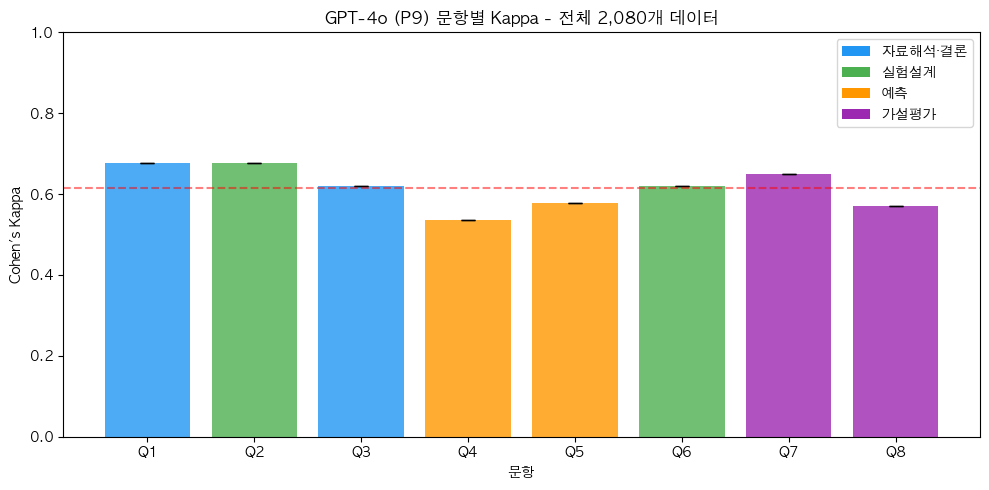

In [8]:
# 문항별 kappa (3회 평균)
q_order = ['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8']
q_kappa_rows = []

for q in q_order:
    kappas = []
    for run_id, rdf in all_runs.items():
        qsub = rdf[rdf['Q'] == q].dropna(subset=['y_pred'])
        if len(qsub) > 0:
            k = cohen_kappa_score(qsub['y_true'], qsub['y_pred'])
            kappas.append(k)
    q_kappa_rows.append({
        'Q': q, 'Type': type_map[q], 'N': len(df_full[df_full['Q'] == q]),
        'Kappa_Mean': np.mean(kappas), 'Kappa_Std': np.std(kappas),
        'Kappa_Min': np.min(kappas), 'Kappa_Max': np.max(kappas)
    })

q_kappa_df = pd.DataFrame(q_kappa_rows)
print("=== 문항별 Kappa (GPT-4o, P9, 3회 평균) ===")
print(q_kappa_df.to_string(index=False, float_format='%.4f'))

# 시각화
fig, ax = plt.subplots(figsize=(10, 5))
colors = {'자료해석·결론': '#2196F3', '실험설계': '#4CAF50', '예측': '#FF9800', '가설평가': '#9C27B0'}
bar_colors = [colors[type_map[q]] for q in q_order]

bars = ax.bar(q_order, q_kappa_df['Kappa_Mean'], 
              yerr=q_kappa_df['Kappa_Std'], capsize=5, color=bar_colors, alpha=0.8)
ax.axhline(y=q_kappa_df['Kappa_Mean'].mean(), color='red', linestyle='--', alpha=0.5, label='전체 평균')
ax.set_ylabel('Cohen\'s Kappa')
ax.set_xlabel('문항')
ax.set_title('GPT-4o (P9) 문항별 Kappa - 전체 2,080개 데이터')
ax.set_ylim(0, 1)

# 범례
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=t) for t, c in colors.items()]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'llm_kappa_by_question.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. 유형별 Kappa 분석

4개 문항 유형의 Kappa를 비교하고, A폼/B폼 간 차이를 분석합니다.
- **자료해석/결론**: Kappa ≈ 0.65 (가장 높음)
- **실험설계**: Kappa ≈ 0.65
- **예측**: Kappa ≈ 0.57 (가장 낮음)
- **가설평가**: Kappa ≈ 0.61
- A폼(Q1~Q4) vs B폼(Q5~Q8): A폼이 약간 높은 성능

In [9]:
# 유형별 kappa (3회 평균)
type_order = ['자료해석·결론', '실험설계', '예측', '가설평가']
type_kappa_rows = []

for qt in type_order:
    kappas = []
    for run_id, rdf in all_runs.items():
        tsub = rdf[rdf['q_type'] == qt].dropna(subset=['y_pred'])
        if len(tsub) > 0:
            k = cohen_kappa_score(tsub['y_true'], tsub['y_pred'])
            kappas.append(k)
    n_total = len(df_full[df_full['q_type'] == qt])
    type_kappa_rows.append({
        'Type': qt, 'N': n_total,
        'Kappa_Mean': np.mean(kappas), 'Kappa_Std': np.std(kappas)
    })

type_kappa_df = pd.DataFrame(type_kappa_rows)
print("=== 유형별 Kappa (GPT-4o, P9, 3회 평균) ===")
print(type_kappa_df.to_string(index=False, float_format='%.4f'))

# A폼 vs B폼
form_kappa_rows = []
for form_name, form_qs in [('A폼 (Q1-Q4)', ['Q1','Q2','Q3','Q4']), ('B폼 (Q5-Q8)', ['Q5','Q6','Q7','Q8'])]:
    kappas = []
    for run_id, rdf in all_runs.items():
        fsub = rdf[rdf['Q'].isin(form_qs)].dropna(subset=['y_pred'])
        if len(fsub) > 0:
            k = cohen_kappa_score(fsub['y_true'], fsub['y_pred'])
            kappas.append(k)
    form_kappa_rows.append({
        'Form': form_name, 'N': len(df_full[df_full['Q'].isin(form_qs)]),
        'Kappa_Mean': np.mean(kappas), 'Kappa_Std': np.std(kappas)
    })

form_kappa_df = pd.DataFrame(form_kappa_rows)
print("\n=== A폼 vs B폼 Kappa ===")
print(form_kappa_df.to_string(index=False, float_format='%.4f'))

=== 유형별 Kappa (GPT-4o, P9, 3회 평균) ===
   Type   N  Kappa_Mean  Kappa_Std
자료해석·결론 530      0.6493     0.0000
   실험설계 520      0.6542     0.0000
     예측 520      0.5656     0.0000
   가설평가 510      0.6100     0.0000

=== A폼 vs B폼 Kappa ===
      Form    N  Kappa_Mean  Kappa_Std
A폼 (Q1-Q4) 1060      0.6296     0.0000
B폼 (Q5-Q8) 1020      0.6051     0.0000


## 9. ML/BERT 결과와 비교

LLM의 문항별 Kappa를 ML(k=7) 및 BERT(k=7)와 비교합니다.
- **k=7**: 7개 문항으로 훈련하고 나머지 1개 문항으로 테스트 (Leave-One-Question-Out)
- ML/BERT는 학습 데이터를 사용하므로 LLM보다 높은 성능
- LLM의 장점: 문항 간 성능 편차(std)가 가장 작음 → 문항 유형에 덜 민감

### 평균 Kappa 비교
- BERT: 0.87 (최고)
- ML Best: 0.80
- LLM: 0.62 (최저, 하지만 학습 없이 달성)

### 문항 간 편차 비교
- LLM: std = 0.05 → 가장 안정적
- BERT: std = 0.04
- ML Best: std = 0.04

In [10]:
# ML 결과 로드 (question combo - 7개 훈련 → 1개 테스트)
ml_results_path = BASE_DIR / 'question_combo_results_parallel24' / 'qc_all_results_question_combo_parallel24.csv'
ml_df = pd.read_csv(ml_results_path)

# Single question 결과 (k=7)
ml_k7 = ml_df[ml_df['N_Train_Qs'] == 7].copy()

# 문항별 best ML kappa
ml_q_best = ml_k7.groupby('Test_Qs').agg(
    ML_Kappa_Best=('Test_Kappa', 'max'),
    ML_Kappa_Mean=('Test_Kappa', 'mean')
).reset_index()
ml_q_best.rename(columns={'Test_Qs': 'Q'}, inplace=True)

# BERT 결과 로드 (여러 results 폴더에 분산)
bert_all = []
for rdir in sorted((BASE_DIR / 'BERT_Results').glob('results *')):
    bpath = rdir / 'bert_question_results.csv'
    if bpath.exists():
        bert_all.append(pd.read_csv(bpath))
if bert_all:
    bert_df = pd.concat(bert_all, ignore_index=True)
    bert_k7 = bert_df[bert_df['N_Train_Qs'] == 7]
    bert_q = bert_k7.groupby('Test_Qs').agg(
        BERT_Kappa=('Test_Kappa', 'mean')
    ).reset_index()
    bert_q.rename(columns={'Test_Qs': 'Q'}, inplace=True)
else:
    bert_q = pd.DataFrame(columns=['Q', 'BERT_Kappa'])

# LLM 문항별 kappa
llm_q = q_kappa_df[['Q', 'Kappa_Mean']].rename(columns={'Kappa_Mean': 'LLM_Kappa'})

# 통합 비교 테이블
compare_df = llm_q.merge(ml_q_best, on='Q', how='left').merge(bert_q, on='Q', how='left')
compare_df['Type'] = compare_df['Q'].map(type_map)
compare_df = compare_df[['Q', 'Type', 'LLM_Kappa', 'ML_Kappa_Best', 'ML_Kappa_Mean', 'BERT_Kappa']]

print("=== 문항별 Kappa 비교: LLM vs ML(k=7) vs BERT(k=7) ===")
print(compare_df.to_string(index=False, float_format='%.4f'))
print(f"\n평균:")
print(f"  LLM:      {compare_df['LLM_Kappa'].mean():.4f}")
print(f"  ML Best:  {compare_df['ML_Kappa_Best'].mean():.4f}")
print(f"  ML Mean:  {compare_df['ML_Kappa_Mean'].mean():.4f}")
print(f"  BERT:     {compare_df['BERT_Kappa'].mean():.4f}")
print(f"\nStd (문항 간 편차):")
print(f"  LLM:      {compare_df['LLM_Kappa'].std():.4f}")
print(f"  ML Best:  {compare_df['ML_Kappa_Best'].std():.4f}")
print(f"  BERT:     {compare_df['BERT_Kappa'].std():.4f}")

=== 문항별 Kappa 비교: LLM vs ML(k=7) vs BERT(k=7) ===
 Q    Type  LLM_Kappa  ML_Kappa_Best  ML_Kappa_Mean  BERT_Kappa
Q1 자료해석·결론     0.6767         0.7653         0.6842      0.8651
Q2    실험설계     0.6781         0.7867         0.7471      0.8943
Q3 자료해석·결론     0.6195         0.8107         0.7156      0.8350
Q4      예측     0.5371         0.7127         0.6698      0.8147
Q5      예측     0.5791         0.8500         0.6752      0.8643
Q6    실험설계     0.6193         0.8144         0.7445      0.9268
Q7    가설평가     0.6499         0.8189         0.6873      0.9089
Q8    가설평가     0.5694         0.8175         0.7295      0.8747

평균:
  LLM:      0.6161
  ML Best:  0.7970
  ML Mean:  0.7067
  BERT:     0.8730

Std (문항 간 편차):
  LLM:      0.0514
  ML Best:  0.0421
  BERT:     0.0371


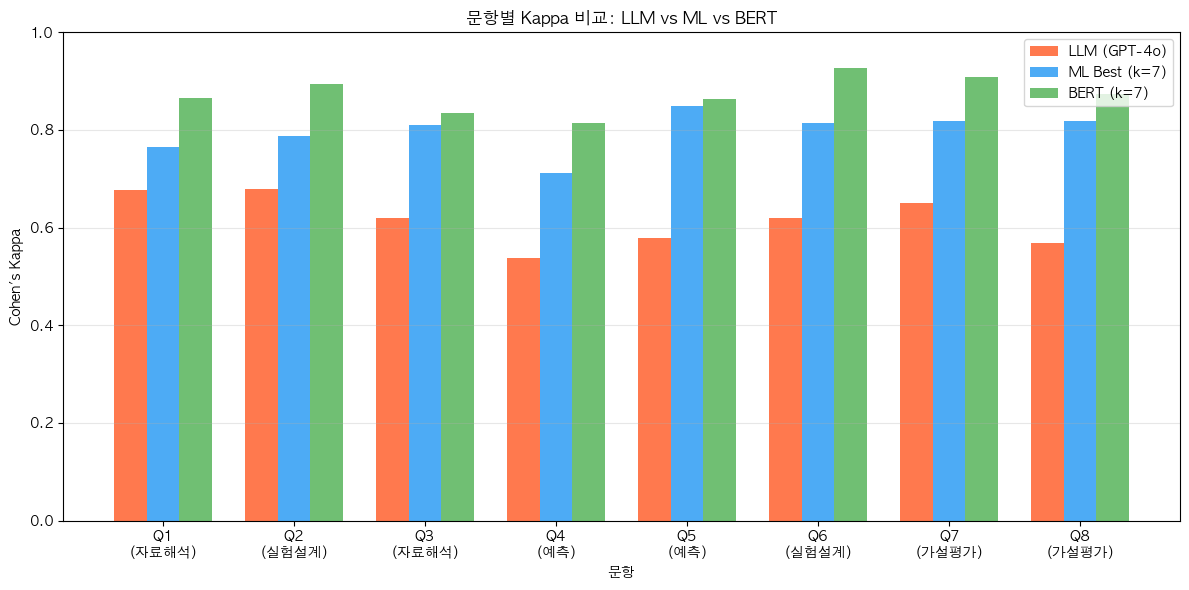

In [11]:
# 비교 시각화
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(q_order))
width = 0.25

bars1 = ax.bar(x - width, compare_df['LLM_Kappa'], width, label='LLM (GPT-4o)', color='#FF5722', alpha=0.8)
bars2 = ax.bar(x, compare_df['ML_Kappa_Best'], width, label='ML Best (k=7)', color='#2196F3', alpha=0.8)
if 'BERT_Kappa' in compare_df.columns and compare_df['BERT_Kappa'].notna().any():
    bars3 = ax.bar(x + width, compare_df['BERT_Kappa'], width, label='BERT (k=7)', color='#4CAF50', alpha=0.8)

ax.set_ylabel("Cohen's Kappa")
ax.set_xlabel('문항')
ax.set_title('문항별 Kappa 비교: LLM vs ML vs BERT')
ax.set_xticks(x)
ax.set_xticklabels([f"{q}\n({type_map[q][:4]})" for q in q_order])
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'llm_ml_bert_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. 레이블별 성능 분석

Classification Report와 혼동 행렬로 레이블별 성능을 상세 분석합니다.
- **혼동 행렬 (개수)**: 실제 vs 예측의 절대 빈도
- **혼동 행렬 (Recall)**: 각 실제 레이블에서 올바르게 예측한 비율
- 주요 혼동 패턴:
  - 3→4, 4→3: 문제 지적과 해결 방향의 경계 혼동
  - 4→5, 5→4: 해결 방향과 구체적 대안의 경계 혼동
  - 1→3, 3→1: 평가와 문제 지적의 혼동

=== Classification Report (Run 1) ===
              precision    recall  f1-score   support

           0      0.492     1.000     0.659        60
           1      0.858     0.811     0.834       513
           2      0.668     0.789     0.723       285
           3      0.887     0.581     0.702       731
           4      0.339     0.702     0.457       181
           5      0.707     0.617     0.659       277
           6      0.675     0.818     0.740        33

    accuracy                          0.698      2080
   macro avg      0.661     0.760     0.682      2080
weighted avg      0.763     0.698     0.710      2080



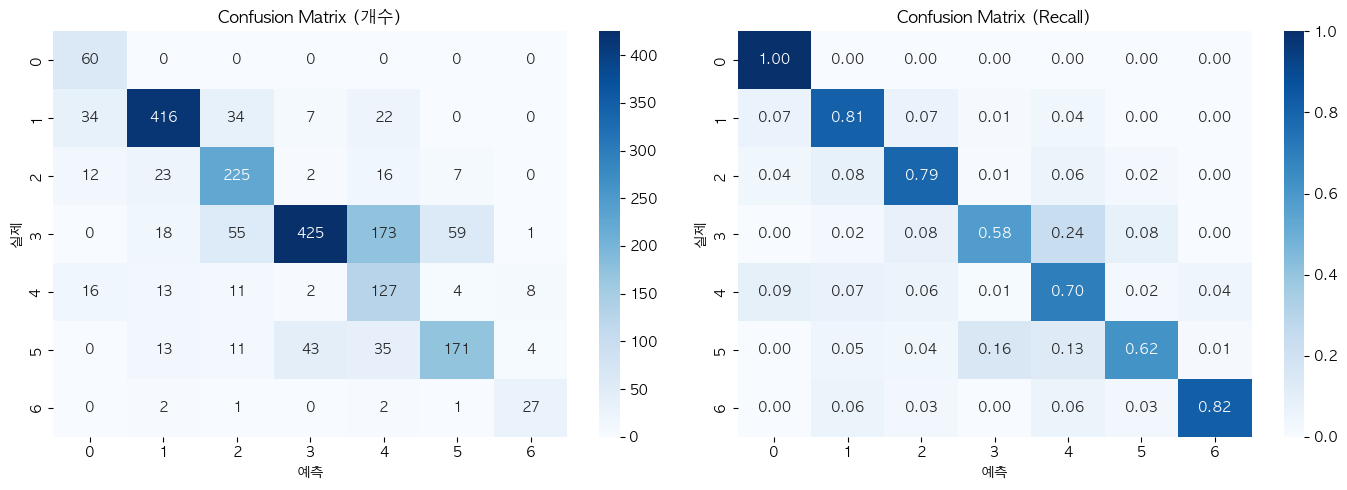

In [12]:
# Run 1 기준 classification report (3회 모두 유사하므로 대표값)
run1 = all_runs[1].dropna(subset=['y_pred'])
print("=== Classification Report (Run 1) ===")
print(classification_report(run1['y_true'], run1['y_pred'], digits=3))

# Confusion matrix heatmap
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(run1['y_true'], run1['y_pred'], labels=range(7))
cm_pct = cm / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(7), yticklabels=range(7), ax=axes[0])
axes[0].set_xlabel('예측')
axes[0].set_ylabel('실제')
axes[0].set_title('Confusion Matrix (개수)')

sns.heatmap(cm_pct, annot=True, fmt='.2f', cmap='Blues', xticklabels=range(7), yticklabels=range(7), ax=axes[1])
axes[1].set_xlabel('예측')
axes[1].set_ylabel('실제')
axes[1].set_title('Confusion Matrix (Recall)')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'llm_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. 결과 저장

분석 결과를 CSV 파일로 저장합니다.
- `llm_wide_predictions.csv`: 3회 예측 비교 (Wide format)
- `llm_kappa_by_question.csv`: 문항별 Kappa
- `llm_ml_bert_comparison.csv`: LLM/ML/BERT 비교 테이블
- `llm_overall_summary.csv`: 전체 성능 요약

In [13]:
# 통합 결과 저장
# 1. Wide format predictions (3회 비교용)
wide_df = df_full[['id', 'label', 'Q', 'q_type']].copy()
wide_df.rename(columns={'label': 'y_true'}, inplace=True)
for run_id in range(1, N_RUNS + 1):
    wide_df = wide_df.merge(
        all_runs[run_id][['id', 'y_pred']].rename(columns={'y_pred': f'pred_run{run_id}'}),
        on='id', how='left'
    )

pred_cols = [f'pred_run{i}' for i in range(1, N_RUNS + 1)]
wide_df['all_same'] = wide_df[pred_cols].nunique(axis=1) == 1
wide_df['majority_pred'] = wide_df[pred_cols].mode(axis=1)[0]
wide_df.to_csv(RESULTS_DIR / 'llm_wide_predictions.csv', index=False, encoding='utf-8-sig')

# 2. 문항별 kappa 테이블
q_kappa_df.to_csv(RESULTS_DIR / 'llm_kappa_by_question.csv', index=False, encoding='utf-8-sig')

# 3. 비교 테이블
compare_df.to_csv(RESULTS_DIR / 'llm_ml_bert_comparison.csv', index=False, encoding='utf-8-sig')

# 4. 전체 요약
summary_df.to_csv(RESULTS_DIR / 'llm_overall_summary.csv', index=False, encoding='utf-8-sig')

print("=== 저장 완료 ===")
for f in sorted(RESULTS_DIR.glob('*')):
    print(f"  {f.name}")

=== 저장 완료 ===
  llm_confusion_matrix.png
  llm_kappa_by_question.csv
  llm_kappa_by_question.png
  llm_ml_bert_comparison.csv
  llm_ml_bert_comparison.png
  llm_overall_summary.csv
  llm_predictions_run1.csv
  llm_wide_predictions.csv
